In [ ]:
import pandas as pd
import numpy as np

#miaomiaokkk

url = "../data/sold_test.csv"

df_ABnews = pd.read_csv(url, sep='\t', encoding='utf-8', header=None,
    names=["id", "context", "offensiveness", "stereotype"]
)
 
df_ABnews.insert(0, 'sentence_id', range(len(df_ABnews)))

df_ABnews.head()

,sentence_id,id,context,offensiveness,stereotype
0,0,11976,"Andate pure là, tanto quei fessi degli italian...",1,0
1,1,12142,Che fine spero che faccia il killer nigeriano ...,1,1
2,2,12088,Così i profughi ci svuotano i negozi a Pordenone,1,1
3,3,12030,Così umiliano gli italiani e coccolano i cland...,1,1
4,4,11775,"Danno soldi ai clandestini, ma ai disabili inv...",1,1


In [2]:
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskAB-tweets.tsv"

df_ABtweets = pd.read_csv(url, sep='\t', encoding='utf-8',  header=None,
    names=["id", "context", "offensiveness", "stereotype"])

df_ABtweets.insert(0, 'sentence_id', range(len(df_ABtweets)))
 
df_ABtweets.head()

,sentence_id,id,context,offensiveness,stereotype
0,0,11834,@user A me pare una scelta politica suicida pu...,1,0
1,1,12113,@user e' un perfetto musulmano!!! chi dice il ...,1,1
2,2,11770,Mai Tg e i giornaloni hanno parlato di questa ...,1,1
3,3,11937,@user Ipocriti farabutti. Fanno morire i terre...,1,1
4,4,11870,@user @user @user L'IMMIGRAZIONE C'E' STATO UN...,1,1


In [3]:
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskC-news.txt"

df_Cnews = pd.read_csv(url, sep='\t', encoding='utf-8', comment="#",
    header=None,
    names=["token_id", "word", "tag"], engine="python", quoting=3)

df_Cnews.insert(0, 'sentence_id', range(len(df_Cnews)))
 
df_Cnews.head()

,sentence_id,token_id,word,tag
0,0,11976-1,"""",O
1,1,11976-2,Andate,O
2,2,11976-3,pure,O
3,3,11976-4,là,O
4,4,11976-5,",",O


In [4]:
url = "https://raw.githubusercontent.com/FrancescaRomanaBlanda/Taboo-Language/main/haspeede2_reference_taskC-tweets.txt"

df_Ctweets = pd.read_csv(url, sep='\t', encoding='utf-8',comment="#",
    header=None,
    names=["token_id", "word", "tag"], engine="python", quoting=3)

df_Ctweets.insert(0, 'sentence_id', range(len(df_Ctweets)))
 
df_Ctweets.head()

,sentence_id,token_id,word,tag
0,0,11834-1,@,O
1,1,11834-2,user,O
2,2,11834-3,A,O
3,3,11834-4,me,O
4,4,11834-5,pare,O


In [5]:
df_Ctweets['id'] = df_Ctweets['token_id'].str.split('-').str[0].astype(int)

df_ABCtweets = df_Ctweets[df_Ctweets['tag'].isin(['B-NU-CGA', 'I-NU-CGA'])]

spans = (
    df_ABCtweets
    .groupby('id')['word']
    .apply(lambda x: ' '.join(x))
    .reset_index()
    .rename(columns={'word': 'offensive_span'})
)

merged_dftweets = df_ABtweets.merge(spans, on='id', how='left')
merged_dftweets.head(10)

,sentence_id,id,context,offensiveness,stereotype,offensive_span
0,0,11834,@user A me pare una scelta politica suicida pu...,1,0,"Meglio così ,"
1,1,12113,@user e' un perfetto musulmano!!! chi dice il ...,1,1,NaN
2,2,11770,Mai Tg e i giornaloni hanno parlato di questa ...,1,1,"Sanremo , Segregata e stuprata per mesi . La g..."
3,3,11937,@user Ipocriti farabutti. Fanno morire i terre...,1,1,Ipocriti farabutti .
4,4,11870,@user @user @user L'IMMIGRAZIONE C'E' STATO UN...,1,1,NaN
5,5,12122,@user @user SI CERTO E TUTTIQUELLI CHE GIRANO ...,1,1,ESPATRIOOOOOOO . . . . BASTAAAAAA
6,6,12095,Ha ragione! É il corano che prescrive la lotta...,1,1,NaN
7,7,11609,Per quanto mi riguarda l'accogliere indiscrimi...,1,1,"Migranti , Fico :"
8,8,12141,IO DOMANDO A QUESTE MERDE che vogliono e accet...,1,1,NaN
9,9,11868,Eccerto poverini poi i migranti si incattivisc...,1,1,NaN


In [6]:
df_Cnews['id'] = df_Cnews['token_id'].str.split('-').str[0].astype(int)

df_ABCnews = df_Cnews[df_Cnews['tag'].isin(['B-NU-CGA', 'I-NU-CGA'])]

spans = (
    df_ABCnews
    .groupby('id')['word']
    .apply(lambda x: ' '.join(x))
    .reset_index()
    .rename(columns={'word': 'offensive_span'})
)

merged_dfnews = df_ABnews.merge(spans, on='id', how='left')
merged_dfnews.head(10)

,sentence_id,id,context,offensiveness,stereotype,offensive_span
0,0,11976,"Andate pure là, tanto quei fessi degli italian...",1,0,NaN
1,1,12142,Che fine spero che faccia il killer nigeriano ...,1,1,La furia cieca della Meloni : le sue parole pi...
2,2,12088,Così i profughi ci svuotano i negozi a Pordenone,1,1,NaN
3,3,12030,Così umiliano gli italiani e coccolano i cland...,1,1,"La follia del governo : "" Per loro gratis . . ..."
4,4,11775,"Danno soldi ai clandestini, ma ai disabili inv...",1,1,"Bracconeri , il figlio autistico e il durissim..."
5,5,11630,"Emergenza, Minniti annulla il viaggio e torna ...",1,1,"Emergenza , Immigrati , invasione alle porte :..."
6,6,11695,"Gli immigrati sono matti, parola di scienziati...",1,1,"parola di scienziati . Malattie mentali e "" ri..."
7,7,11866,Ho chiesto ai profughi di lavorare ma preferis...,1,1,NaN
8,8,12174,Immigrati bomba sociale Subito via 600mila irr...,1,1,""" Immigrati bomba sociale Subito via 600mila i..."
9,9,11663,"Immigrati, così la sinistra ci costringe a ten...",1,1,"Immigrati , Meloni , la denuncia : "" Il trucco..."


In [7]:
merged_df = pd.concat([merged_dfnews, merged_dftweets], ignore_index=True)
merged_df.insert(1, 'Language', 'ITA')
merged_df = merged_df.drop(columns=['id'])
#merged_df = merged_df.drop(columns=['offensive'])  
merged_df.head(100)


,sentence_id,Language,context,offensiveness,stereotype,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",1,0,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,1,1,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,1,1,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,1,1,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",1,1,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,0,0,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",0,0,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",0,0,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,0,0,NaN


In [8]:
merged_df['offensiveness'] = merged_df['offensiveness'].fillna(0).astype(int)

def map_stereotype(row):
    if row['stereotype'] == 0 and row['offensiveness'] == 0:
        return "null"
    elif row['stereotype'] == 1:
        return "GRP"
    else:
        return "IND"

merged_df['stereotype'] = merged_df.apply(map_stereotype, axis=1)
merged_df['offensiveness'] = merged_df['offensiveness'].fillna('NOT')
merged_df['offensiveness'] = merged_df['offensiveness'].map({1: 'OFF', 0: 'NOT'})
merged_df = merged_df.rename(columns={'stereotype': 'target_type'})
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,NaN


In [9]:
merged_df.insert(merged_df.columns.get_loc('target_type')+1, 'target_group_attribute', np.nan)
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,NaN,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,NaN,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,NaN,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,NaN,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,NaN,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,NaN,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,NaN,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,NaN,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,NaN,NaN


In [10]:
merged_df[["context", "target_group_attribute"]].to_csv(
    "context_target_group_attribute.csv",
    index=False
)

In [11]:
import pandas as pd

# Load the CSV
df = pd.read_csv(r"C:\Users\duebl\Downloads\context_target_group_attribute_labeled_v4 (1).csv")

# Count occurrences of each category
counts = df["target_group_attribute"].value_counts()

print(counts)

target_group_attribute
Immigrants                       1193
Religion                          217
Race, Ethnicity & Nationality     187
Gender & Sexual Orientation        88
Political Affiliation              31
Miscellaneous                      26
Nomads                             15
Socioeconomic status                6
Name: count, dtype: int64


In [12]:
import pandas as pd

# Load the CSV
df = pd.read_csv(r"C:\Users\duebl\Downloads\context_target_group_attribute_labeled_v4_with_target_group.csv")

# Count occurrences of each category
counts = df["target_group"].value_counts()

print(counts)

target_group
Immigrants             1193
Others                  212
Islam                   190
Men                      57
Roma                     32
Other political          30
lgbtq+                   14
Nomads (general)         11
Other socioeconomic       6
Black                     5
Roma/Travellers           4
Chinese                   4
Christianity              2
Women                     1
Right-wing                1
Arab                      1
Name: count, dtype: int64


In [13]:
counts=merged_df["offensiveness"].value_counts()
print(counts)

offensiveness
NOT    960
OFF    803
Name: count, dtype: int64


In [14]:
import pandas as pd

# Load CSV
df_csv = pd.read_csv(r"C:\Users\duebl\Downloads\context_target_group_attribute_labeled_v4 (1).csv")

# Add the column to your main dataframe
merged_df["target_group_attribute"] = df_csv["target_group_attribute"]

merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,NaN


In [15]:
df_csv = pd.read_csv(r"C:\Users\duebl\Downloads\context_target_group_attribute_labeled_v4_with_target_group.csv")

merged_df["target_group"] = df_csv["target_group"]

cols = list(merged_df.columns)
new_pos = cols.index("target_group_attribute") + 1
cols.insert(new_pos, cols.pop(cols.index("target_group")))
merged_df = merged_df[cols]
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,Other political,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,Immigrants,NaN


In [16]:
merged_df = merged_df.drop(columns=["predicted_category", "confidence"], errors="ignore")
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,Other political,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,Immigrants,NaN


In [17]:
# Find rows where context contains 'rom' (case insensitive, handles NaN safely)
mask = merged_df["context"].str.contains(r"\brom\b", case=False, na=False)

# Reassign values
merged_df.loc[mask, "target_group_attribute"] = "Nomads"
merged_df.loc[mask, "target_group"] = "Nomads (general)"


In [18]:
merged_df["target_group"] = merged_df["target_group"].replace(
    "Nomads (general)", 
    "Nomads"
)
merged_df["target_group"] = merged_df["target_group"].replace(
    "lgbtq+", 
    "LGBTQ+"
)
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Political Affiliation,Other political,La furia cieca della Meloni : le sue parole pi...
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Immigrants,Immigrants,NaN
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Immigrants,Immigrants,"La follia del governo : "" Per loro gratis . . ..."
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Immigrants,Immigrants,"Bracconeri , il figlio autistico e il durissim..."
...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Immigrants,Immigrants,NaN
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Immigrants,Immigrants,NaN
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Immigrants,Immigrants,NaN
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Immigrants,Immigrants,NaN


In [19]:
# Count occurrences of each category
counts = merged_df["target_group"].value_counts()

print(counts)

target_group
Immigrants             1162
Nomads                  263
Islam                   188
Others                   58
Men                      52
Other political          15
LGBTQ+                   13
Roma/Travellers           4
Other socioeconomic       3
Christianity              2
Black                     1
Women                     1
Right-wing                1
Name: count, dtype: int64


In [20]:
merged_df.to_csv("final_dataframe.csv", index=False)


In [21]:
# First method
import json
import requests

base_url = "https://raw.githubusercontent.com/dhfbk/MuLTa-Telegram/main/data/it"

def load_json_file(filename):
    full_url = f"{base_url}/{filename}"
    response = requests.get(full_url)
    response.raise_for_status()  # Raise an exception for HTTP errors
    data = response.json()
    return pd.DataFrame(data)

train_df = load_json_file("train.json")
dev_df = load_json_file("dev.json")
test_df = load_json_file("test.json")

print(train_df.columns)
print(train_df.head())

Index(['id', 'text', 'hate label', 'hate target', 'mentioned group', 'split',
       'language'],
      dtype='object')
   id                                               text  hate label  \
0   1                       Mah che c'è ne frega a noi ?           0   
1   2  che idioti....cmq, se avessero rifiutato di ve...           1   
2   3  È possibile...al governo ci sono molti nazisti...           0   
3   4  <photo>  Sul profilo ufficiale Instagram del p...           0   
4   5  #Italia #Elezioni2022  Il diciassettesimo part...           0   

  hate target           mentioned group  split language  
0                                  None  train       it  
1       Other  Migrants;People of color  train       it  
2                                  Jews  train       it  
3                                  Jews  train       it  
4                                LGBTQ+  train       it  


In [22]:
print(train_df.columns)
print(train_df.head(10))
print(train_df['hate target'].value_counts())

Index(['id', 'text', 'hate label', 'hate target', 'mentioned group', 'split',
       'language'],
      dtype='object')
   id                                               text  hate label  \
0   1                       Mah che c'è ne frega a noi ?           0   
1   2  che idioti....cmq, se avessero rifiutato di ve...           1   
2   3  È possibile...al governo ci sono molti nazisti...           0   
3   4  <photo>  Sul profilo ufficiale Instagram del p...           0   
4   5  #Italia #Elezioni2022  Il diciassettesimo part...           0   
5   6  Rifiuta la fascia arcobaleno “per motivi relig...           0   
6   7  <video>  Vera Sharav 75° Anniversario Norimber...           0   
7   8  <video>  A Mosca, nel 18° anniversario della t...           0   
8   9  A che punto sono le indagini relative allo spy...           0   
9  10  👍🏻👍🏻👍🏻prendiamo nota di nome e cognome come di...           0   

  hate target           mentioned group  split language  
0                            

In [23]:
mapping = {
    "LGBTQ+": "Gender & Sexual Orientation",
    "Women": "Gender & Sexual Orientation",
    "Ethnicity/ Origin: people of color": "Race, Ethnicity & Nationality",
    "Ethnicity/ Origin: romani": "Race, Ethnicity & Nationality",
    "Jewish": "Religion",
    "Muslims": "Religion",
    "Christians": "Religion",
    "Other": "Miscellaneous",
    "Ethnicity/ Origin: other": "Race, Ethnicity & Nationality",
    "No target": "Miscellaneous",
    "Disability": "Disability"
}

In [24]:
def map_target(row):
    target = row['mentioned group']
    if pd.isna(target) or str(target).strip() == "" or str(target).lower() == "none":
        target = row['hate target']
    if pd.isna(target) or str(target).strip() == "" or str(target).lower() == "no target":
        return "Miscellaneous"
    if target in mapping:
        return mapping[target]
    else:
        return "Miscellaneous"

for df in [train_df, dev_df, test_df]:
    df['target_group_attribute'] = df.apply(map_target, axis=1)

In [25]:
train_df[['text','hate target','mentioned group','target_group_attribute']].head(10)
train_df['target_group_attribute'].value_counts()


target_group_attribute
Miscellaneous                    790
Gender & Sexual Orientation      206
Religion                         119
Race, Ethnicity & Nationality      6
Name: count, dtype: int64

In [26]:
pip install transformers datasets torch scikit-learn

In [27]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import torch

C:\Users\duebl\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:260: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [28]:
# Example with train_df, dev_df, test_df
# Keep only needed columns
train_data = train_df[['text', 'target_group_attribute']]
dev_data   = dev_df[['text', 'target_group_attribute']]
test_data  = test_df[['text', 'target_group_attribute']]

# Encode labels as integers
label_encoder = LabelEncoder()
train_data['label'] = label_encoder.fit_transform(train_data['target_group_attribute'])
dev_data['label'] = label_encoder.transform(dev_data['target_group_attribute'])
test_data['label'] = label_encoder.transform(test_data['target_group_attribute'])

# Convert to Hugging Face Dataset
hf_train = Dataset.from_pandas(train_data[['text', 'label']])
hf_dev   = Dataset.from_pandas(dev_data[['text', 'label']])
hf_test  = Dataset.from_pandas(test_data[['text', 'label']])

# Combine into DatasetDict
dataset = DatasetDict({
    'train': hf_train,
    'validation': hf_dev,
    'test': hf_test
})

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1121
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 181
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 700
    })
})


C:\Users\duebl\AppData\Local\Temp\ipykernel_30920\347301474.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['label'] = label_encoder.fit_transform(train_data['target_group_attribute'])
C:\Users\duebl\AppData\Local\Temp\ipykernel_30920\347301474.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dev_data['label'] = label_encoder.transform(dev_data['target_group_attribute'])
C:\Users\duebl\AppData\Local\Temp\ipykernel_30920\347301474.py:11: SettingWithCopyWarning: 
A value is trying to be set

In [29]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [30]:
#model_name = "xlm-roberta-base"

#tokenizer = AutoTokenizer.from_pretrained(model_name)

#num_labels = len(label_encoder.classes_)

#model = AutoModelForSequenceClassification.from_pretrained(
#    model_name,
#    num_labels=num_labels
#)


In [31]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [32]:
# tokenized_dataset = dataset.map(
#     tokenize,
#     batched=True
# )

In [33]:
# tokenized_dataset = tokenized_dataset.remove_columns(["text"])
# tokenized_dataset.set_format("torch")

In [34]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

In [35]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [36]:
training_args = TrainingArguments(
    output_dir="./hate_category_model",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=100,
    save_total_limit=2,
    report_to="none"
)

In [37]:
#trainer = Trainer(
#    model=model,
#    args=training_args,
#    train_dataset=tokenized_dataset["train"],
#    eval_dataset=tokenized_dataset["validation"],
#    tokenizer=tokenizer,
#    compute_metrics=compute_metrics
#)

In [38]:
#trainer.train()

In [39]:
#trainer.evaluate(tokenized_dataset["test"])

In [40]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer

model_path = "./hate_category_model/checkpoint-284"

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [41]:
trainer = Trainer(
    model=model,
    args=training_args,
    tokenizer=tokenizer
)

C:\Users\duebl\anaconda3\Lib\site-packages\accelerate\accelerator.py:457: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None)
  warnings.warn(


In [42]:
from datasets import Dataset
merged_df["context"] = merged_df["context"].fillna("").astype(str)
unlabeled_ds = Dataset.from_pandas(
    merged_df[['context']].rename(columns={'context': 'text'})
)
tokenized_unlabeled = unlabeled_ds.map(
    tokenize,
    batched=True
)
tokenized_unlabeled.set_format("torch")
predictions = trainer.predict(tokenized_unlabeled)
pred_labels = np.argmax(predictions.predictions, axis=1)
merged_df["predicted_category"] = label_encoder.inverse_transform(pred_labels)
merged_df["confidence"] = predictions.predictions.max(axis=1)
merged_df.loc[
    merged_df["target_type"] == "IND",
    "predicted_category"
] = "Miscellaneous"
merged_df.loc[
    merged_df["confidence"] < 0.5,
    "predicted_category"
] = "Miscellaneous"


Map:   0%|          | 0/1763 [00:00<?, ? examples/s]

C:\Users\duebl\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


In [43]:
merged_df["target_group_attribute"] = merged_df["predicted_category"]
merged_df.head(100)

,sentence_id,Language,context,offensiveness,target_type,target_group_attribute,target_group,offensive_span,predicted_category,confidence
0,0,ITA,"Andate pure là, tanto quei fessi degli italian...",OFF,IND,Miscellaneous,Others,NaN,Miscellaneous,4.591508
1,1,ITA,Che fine spero che faccia il killer nigeriano ...,OFF,GRP,Miscellaneous,Other political,La furia cieca della Meloni : le sue parole pi...,Miscellaneous,4.540971
2,2,ITA,Così i profughi ci svuotano i negozi a Pordenone,OFF,GRP,Miscellaneous,Immigrants,NaN,Miscellaneous,4.497476
3,3,ITA,Così umiliano gli italiani e coccolano i cland...,OFF,GRP,Miscellaneous,Immigrants,"La follia del governo : "" Per loro gratis . . ...",Miscellaneous,4.606574
4,4,ITA,"Danno soldi ai clandestini, ma ai disabili inv...",OFF,GRP,Miscellaneous,Immigrants,"Bracconeri , il figlio autistico e il durissim...",Miscellaneous,4.631391
...,...,...,...,...,...,...,...,...,...,...
95,95,ITA,Il migrante adolescente morto in mare con la p...,NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.561772
96,96,ITA,"Latina, centinaia di stranieri sfruttati nei c...",NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.647356
97,97,ITA,"Morta Maritsa, la nonna di Lesbo che allattava...",NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,3.993213
98,98,ITA,Al corteo per Matera Capitale della cultura i ...,NOT,null,Miscellaneous,Immigrants,NaN,Miscellaneous,4.585063


In [44]:
merged_df["predicted_category"].value_counts()

predicted_category
Miscellaneous                  1461
Religion                        216
Gender & Sexual Orientation      86
Name: count, dtype: int64

In [45]:
# EDA for Italian Taboo Sentences
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

Category counts:
target_group_attribute
Miscellaneous                  1461
Religion                        216
Gender & Sexual Orientation      86
Name: count, dtype: int64


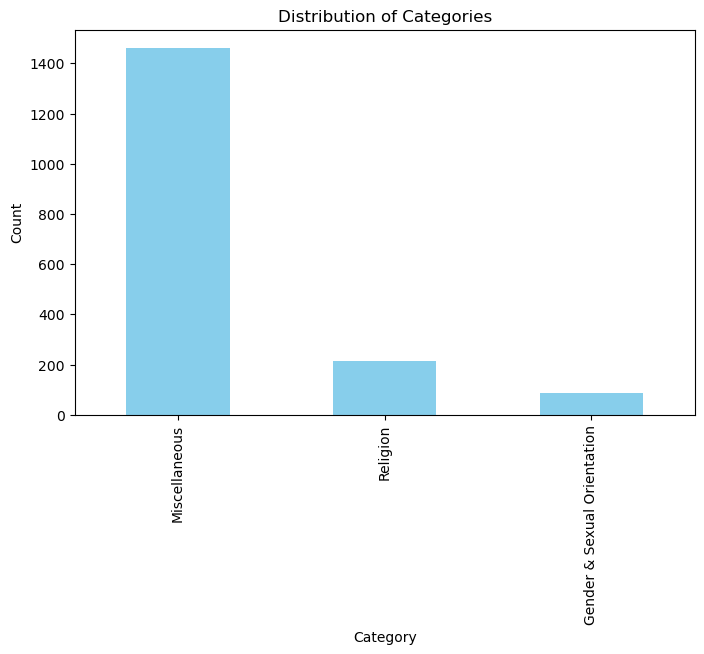

In [46]:
# Category Frequency
print("Category counts:")
print(merged_df["target_group_attribute"].value_counts())

plt.figure(figsize=(8,5))
merged_df["target_group_attribute"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Distribution of Categories")
plt.ylabel("Count")
plt.xlabel("Category")
plt.show()


Confidence statistics:
count    1763.000000
mean        4.224895
std         0.640627
min         1.452582
25%         3.991177
50%         4.550217
75%         4.615287
max         4.709577
Name: confidence, dtype: float64


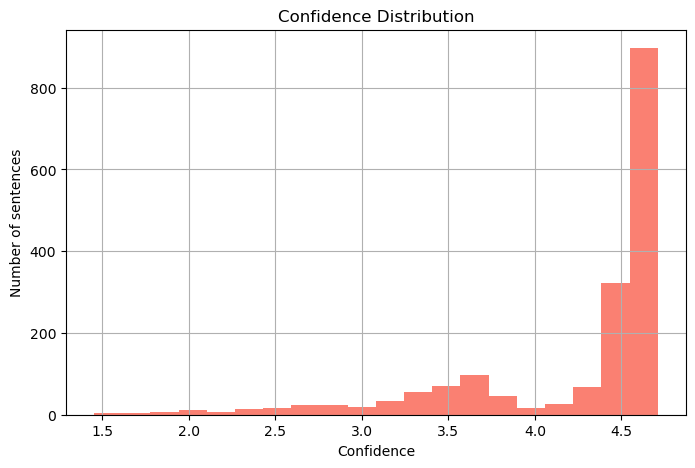

In [47]:
# Confidence Analysis
print("\nConfidence statistics:")
print(merged_df["confidence"].describe())

plt.figure(figsize=(8,5))
merged_df["confidence"].hist(bins=20, color="salmon")
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of sentences")
plt.show()

In [48]:
# Mean confidence per category
print("\nMean confidence per category:")
print(merged_df.groupby("target_group_attribute")["confidence"].mean())


Mean confidence per category:
target_group_attribute
Gender & Sexual Orientation    3.123569
Miscellaneous                  4.419595
Religion                       3.346456
Name: confidence, dtype: float32


In [49]:
# Cross Analysis: Attribute × Target Group
print("\nCross-tab of Attribute vs Target Group:")
print(pd.crosstab(merged_df["target_group"], merged_df["target_group_attribute"]))


Cross-tab of Attribute vs Target Group:
target_group_attribute  Gender & Sexual Orientation  Miscellaneous  Religion
target_group                                                                
Black                                             0              1         0
Christianity                                      0              1         1
Immigrants                                       39           1072        51
Islam                                             0             45       143
LGBTQ+                                           12              1         0
Men                                              11             41         0
Nomads                                           15            245         3
Other political                                   0             15         0
Other socioeconomic                               0              3         0
Others                                            8             32        18
Right-wing                         

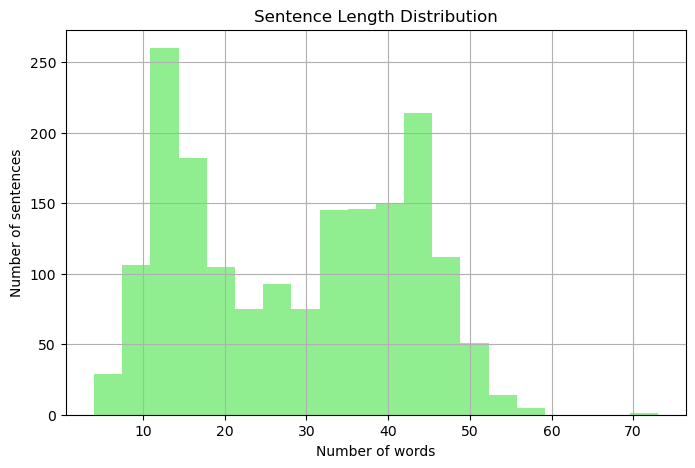

In [50]:
# Sentence Length Analysis
merged_df["length"] = merged_df["context"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
merged_df["length"].hist(bins=20, color="lightgreen")
plt.title("Sentence Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.show()

In [51]:
# Mean sentence length per category
print("\nMean sentence length per category:")
print(merged_df.groupby("target_group_attribute")["length"].mean())


Mean sentence length per category:
target_group_attribute
Gender & Sexual Orientation    32.023256
Miscellaneous                  27.713895
Religion                       32.430556
Name: length, dtype: float64


In [52]:
# Most Frequent Words
def get_words(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", "", text)  # remove punctuation
    return text.split()

words = merged_df["context"].apply(get_words)

all_words = Counter([w for sublist in words for w in sublist])
print("\n20 most common words overall:")
print(all_words.most_common(20))


20 most common words overall:
[('e', 1452), ('di', 1325), ('i', 1079), ('a', 989), ('che', 965), ('user', 940), ('la', 795), ('il', 784), ('non', 776), ('in', 651), ('per', 617), ('migranti', 584), ('url', 569), ('è', 518), ('un', 442), ('sono', 393), ('con', 386), ('gli', 347), ('le', 337), ('si', 337)]


In [53]:
# Optional: most common words per category
print("\nMost common words per category:")
for cat in merged_df["target_group_attribute"].unique():
    cat_words = Counter([w for sublist in merged_df[merged_df["target_group_attribute"]==cat]["context"].apply(get_words) for w in sublist])
    print(f"{cat}: {cat_words.most_common(10)}")


Most common words per category:
Miscellaneous: [('e', 1155), ('di', 1080), ('i', 925), ('a', 812), ('che', 795), ('user', 721), ('non', 645), ('il', 632), ('la', 602), ('migranti', 546)]
Religion: [('e', 220), ('di', 183), ('user', 174), ('la', 146), ('è', 126), ('che', 124), ('a', 121), ('il', 109), ('i', 106), ('non', 98)]
Gender & Sexual Orientation: [('e', 77), ('di', 62), ('a', 56), ('i', 48), ('la', 47), ('donne', 46), ('che', 46), ('user', 45), ('il', 43), ('è', 36)]


In [54]:
# Class Imbalance Check
print("\nNormalized class distribution:")
print(merged_df["target_group_attribute"].value_counts(normalize=True))


Normalized class distribution:
target_group_attribute
Miscellaneous                  0.828701
Religion                       0.122518
Gender & Sexual Orientation    0.048780
Name: proportion, dtype: float64


In [55]:
# Low Confidence Inspection
print("\n20 lowest confidence predictions:")
print(merged_df.sort_values("confidence").head(20)[["context","target_group_attribute","confidence"]])


20 lowest confidence predictions:
                                                context  \
1754  @user @user Schifoso gruppo di esseri decerebr...   
846   @user Io posso testimoniare che sul lavoro con...   
1320  Maometto/Mohammed was a pedophile. Islam is th...   
572   La fermezza dell'Italia contro l'invasione di ...   
646   La musulmana @ Nadia_Connects mente spudoratam...   
1304  700 AD: terrorismo islamico 1200 AD: terrorism...   
1354  Uno dei 2 frateli terroristi che hanno compiut...   
1352  @user @user E beh, perché è giusto andare in g...   
1351  Salvini: Non concederò  neanche mezza moschea ...   
675   Questi che facevano venire i terroristi con i ...   
992   UK: Corte Islamica della Sharia: Le leggi ingl...   
614   Gli ebrei portati contro la propria volontà. I...   
1161  “L’Isis non è islam”, dicevano i sussiegosi be...   
1300  @user Classico dei muslims,non si può conviver...   
858   Basta indottrinamento, ormai dalle materne ini...   
1358  @user Le donna 